In [2]:
# Nguyễn Hoàng Tùng

# ===== (a) LOAD + CLEAN + CONVERT + SAVE =====
import os
import re
import math
import pandas as pd
from pathlib import Path

# --- INPUT PATHS (Windows) ---
win_txt_path = r"D:\lecture\PTIT\20251\IntSys\e267_Data on age, gender, height, weight, activity levels for each household member..txt"
win_out_csv  = r"D:\lecture\PTIT\20251\IntSys\data_4.2.csv"

# --- FALLBACK PATHS (for this environment / testing) ---
fallback_txt_path = "/mnt/data/e267_Data on age, gender, height, weight, activity levels for each household member..txt"
fallback_out_csv  = "/mnt/data/data_4.2.csv"

# Resolve readable input path
in_path = win_txt_path if os.path.exists(win_txt_path) else fallback_txt_path
out_path = win_out_csv if os.name == "nt" else fallback_out_csv

# Ensure output directory exists
Path(os.path.dirname(out_path)).mkdir(parents=True, exist_ok=True)

# Load TSV-like file (tab-separated)
df_raw = pd.read_csv(in_path, sep="\t", dtype=str)

# Standardize column names (strip quotes/whitespace)
df_raw.columns = [c.strip().strip('"').strip() for c in df_raw.columns]

# Expected columns (from file header)
# HH_ID, Member_Age_Orig, Member_ID, Member_Gender_Orig, HEIGHT, WEIGHT, Mod_act, Vig_act
for col in ["Member_Age_Orig","Member_Gender_Orig","HEIGHT","WEIGHT","Mod_act","Vig_act"]:
    if col not in df_raw.columns:
        raise ValueError(f"Missing expected column: {col}")

# --- Helpers ---
def parse_height_ft_dot_in(h):
    """
    Parse height strings like '5.11' -> 5 ft 11 in, '6.1' -> 6 ft 1 in, '5' -> 5 ft 0 in.
    Return meters (float) or NaN.
    """
    if pd.isna(h) or str(h).strip()=="":
        return math.nan
    s = str(h).strip()
    # Sometimes values like '4.11' or '6' appear
    if "." in s:
        ft_s, in_s = s.split(".", 1)
        try:
            ft = int(re.sub(r"\D", "", ft_s)) if ft_s.strip() else math.nan
            inch = int(re.sub(r"\D", "", in_s)) if in_s.strip() else 0
        except:
            return math.nan
    else:
        # Only feet provided
        try:
            ft = int(re.sub(r"\D", "", s))
            inch = 0
        except:
            return math.nan
    if pd.isna(ft):
        return math.nan
    total_in = ft*12 + inch
    return total_in * 0.0254  # inches -> meters

def to_float_safe(x):
    try:
        # Remove stray non-numerics
        return float(re.sub(r"[^0-9.\-]", "", str(x))) if str(x).strip()!="" else math.nan
    except:
        return math.nan

# --- Clean / convert ---
df = pd.DataFrame()
df["age"] = df_raw["Member_Age_Orig"].apply(to_float_safe)
df["gender_code"] = df_raw["Member_Gender_Orig"].apply(to_float_safe)  # 1=Male, 2=Female (per file)
df["gender"] = df["gender_code"].map({1.0:"male", 2.0:"female"})
df["height_m"] = df_raw["HEIGHT"].apply(parse_height_ft_dot_in)  # feet.inches -> meters
df["weight_lb"] = df_raw["WEIGHT"].apply(to_float_safe)
df["weight_kg"] = df["weight_lb"] * 0.45359237
df["mod_min_per_week"] = df_raw["Mod_act"].apply(to_float_safe)
df["vig_min_per_week"] = df_raw["Vig_act"].apply(to_float_safe)

# Activity proxy: count vigorous as double credit (CDC guideline weight)
df["activity_score"] = (df["mod_min_per_week"].fillna(0)) + 2.0*(df["vig_min_per_week"].fillna(0))

# Keep only 5 features requested: gender, activity level, age, height, weight
# - gender as binary (male=1, female=0) if missing -> NaN
gender_bin = df["gender"].map({"male":1, "female":0})
data_5 = pd.DataFrame({
    "gender": gender_bin,
    "activity_level": df["activity_score"],
    "age": df["age"],
    "height_m": df["height_m"],
    "weight_kg": df["weight_kg"],
})

# Drop rows lacking essential numeric fields (age, height, weight)
data_5 = data_5.dropna(subset=["age","height_m","weight_kg"]).reset_index(drop=True)

# Save
data_5.to_csv(out_path, index=False)
print(f"Saved cleaned dataset with 5 features to: {out_path}")
print(data_5.head())


Saved cleaned dataset with 5 features to: D:\lecture\PTIT\20251\IntSys\data_4.2.csv
   gender  activity_level   age  height_m  weight_kg
0     1.0            32.0  37.0    1.5494  86.182550
1     0.0            34.0  37.0    1.6510  77.110703
2     1.0            80.0  28.0    1.8034  86.182550
3     0.0            40.0  26.0    1.6510  63.502932
4     1.0            38.0  47.0    1.7018  70.306817


Data snapshot:
   gender  activity_level   age  height_m  weight_kg        BMI  job_level  \
0     1.0            32.0  37.0    1.5494  86.182550  35.899817  sedentary   
1     0.0            34.0  37.0    1.6510  77.110703  28.289190  sedentary   
2     1.0            80.0  28.0    1.8034  86.182550  26.499349  sedentary   
3     0.0            40.0  26.0    1.6510  63.502932  23.296980  sedentary   
4     1.0            38.0  47.0    1.7018  70.306817  24.276183  sedentary   
5     0.0            19.0  44.0    1.5748  54.431084  21.948062  sedentary   
6     1.0            12.0  19.0    1.7018  56.699046  19.577567  sedentary   
7     1.0             5.0  15.0    1.6510  55.338269  20.301654  sedentary   
8     0.0            48.0  75.0    1.6256  58.059823  21.970924  sedentary   
9     1.0            48.0  77.0    1.7018  76.203518  26.312250  sedentary   

    bmi_class  
0  overweight  
1  overweight  
2  overweight  
3      normal  
4      normal  
5      normal  
6      normal 

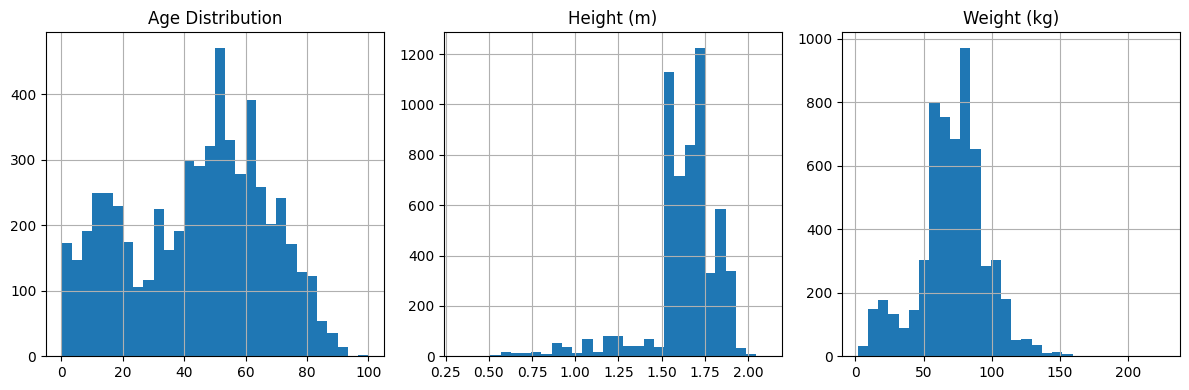

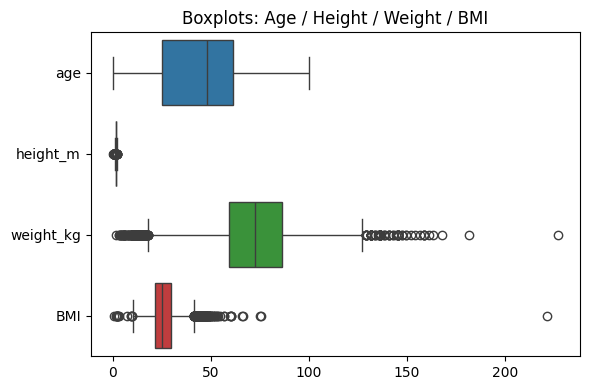

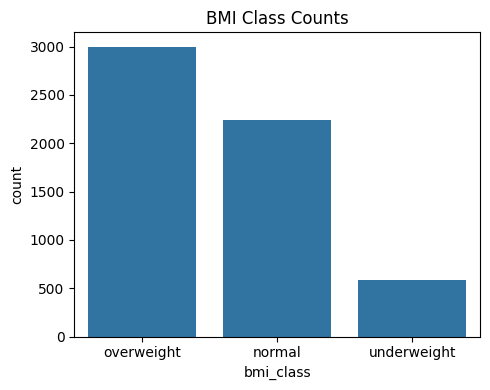

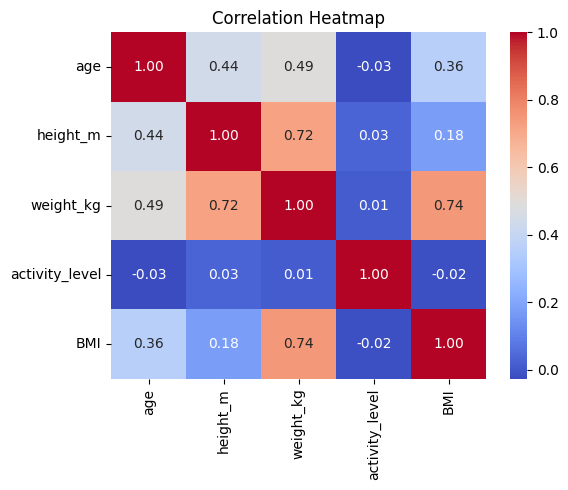

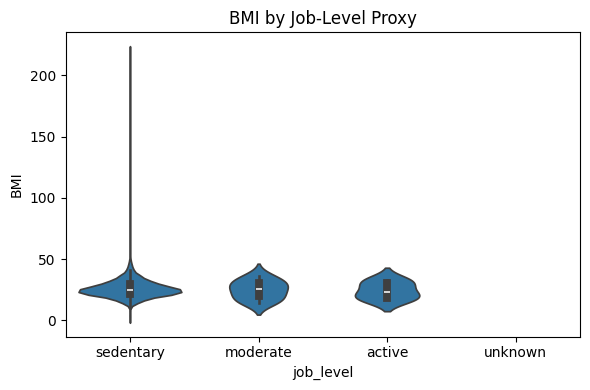


=== Model Comparison (c & d) ===
       Model  Accuracy      MAE      MSE     RMSE
         CNN  0.985420 0.014580 0.014580 0.120747
   GradBoost  0.972556 0.027444 0.027444 0.165663
RandomForest  0.963122 0.036878 0.036878 0.192037
     SVM-RBF  0.957976 0.048885 0.062607 0.250214
      LogReg  0.956261 0.047170 0.054031 0.232445
         KNN  0.908233 0.094340 0.099485 0.315413
         RNN  0.880789 0.126930 0.142367 0.377316
        LSTM  0.697256 0.311321 0.328473 0.573126

Best model: CNN
Health-guide KB saved to: D:\lecture\PTIT\20251\IntSys\kb_healthGuide.json
Prediction: overweight | BMI: 25.5 | Job-level: sedentary
Guide: {'general': ['Create a modest calorie deficit via diet quality and portion control.', 'Target ≥150–300 min/wk moderate aerobic activity; include 2–3 days resistance training.', 'Limit sugary drinks and ultra-processed foods; prioritize fiber and protein.'], 'age_note': 'Combine diet changes with consistent activity; track habits.', 'job_note': 'Schedule wal

In [11]:
# Nguyễn Hoàng Tùng

import os, json, math, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models, utils as kutils
from tensorflow.keras.callbacks import EarlyStopping

# ---------- Load dataset ----------
win_out_csv  = r"D:\lecture\PTIT\20251\IntSys\data_4.2.csv"
fallback_out_csv  = "/mnt/data/data_4.2.csv"
csv_path = win_out_csv if os.path.exists(win_out_csv) else fallback_out_csv

df = pd.read_csv(csv_path)

# ---------- (b) Show distribution of the dataset ----------
df["BMI"] = df["weight_kg"] / (df["height_m"]**2)

def job_from_activity(score):
    if pd.isna(score): return "unknown"
    if score < 150: return "sedentary"
    if score < 300: return "moderate"
    return "active"

df["job_level"] = df["activity_level"].apply(job_from_activity)

def bmi_class(bmi):
    if pd.isna(bmi): return np.nan
    if bmi < 18.5: return "underweight"
    if bmi < 25: return "normal"
    return "overweight"

df["bmi_class"] = df["BMI"].apply(bmi_class)

print("Data snapshot:")
print(df.head(10))
print("\nClass distribution:\n", df["bmi_class"].value_counts(dropna=True))

# ----- Visualizations (≥5) -----
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); df["age"].hist(bins=30); plt.title("Age Distribution")
plt.subplot(1,3,2); df["height_m"].hist(bins=30); plt.title("Height (m)")
plt.subplot(1,3,3); df["weight_kg"].hist(bins=30); plt.title("Weight (kg)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df[["age","height_m","weight_kg","BMI"]], orient="h")
plt.title("Boxplots: Age / Height / Weight / BMI")
plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x="bmi_class", data=df)
plt.title("BMI Class Counts")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df[["age","height_m","weight_kg","activity_level","BMI"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
sns.violinplot(x="job_level", y="BMI", data=df, order=["sedentary","moderate","active","unknown"])
plt.title("BMI by Job-Level Proxy")
plt.tight_layout(); plt.show()

# ---------- (c) 5 classic ML models ----------
work_df = df.dropna(subset=["bmi_class"]).copy()

numeric_features = ["gender","activity_level","age","height_m","weight_kg"]
cat_features = ["job_level"]

X = work_df[numeric_features + cat_features]
y = work_df["bmi_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# Classic ML models
ml_models = {
    "LogReg": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM-RBF": SVC(kernel="rbf", probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradBoost": GradientBoostingClassifier(random_state=42),
}

results = []
y_pred_store = {}

for name, clf in ml_models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_pred_store[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    classes_ = ["underweight","normal","overweight"]
    class_to_idx = {c:i for i,c in enumerate(classes_)}
    y_true_idx = y_test.map(class_to_idx).values
    y_pred_idx = pd.Series(y_pred).map(class_to_idx).values
    mae = mean_absolute_error(y_true_idx, y_pred_idx)
    mse = mean_squared_error(y_true_idx, y_pred_idx)
    rmse = math.sqrt(mse)
    
    results.append((name, acc, mae, mse, rmse))

# ---------- (d) Deep models: CNN, RNN, LSTM ----------
X_train_all = preprocess.fit_transform(X_train)
X_test_all  = preprocess.transform(X_test)

F = X_train_all.shape[1]
Xtr_seq = np.array(X_train_all.todense() if hasattr(X_train_all, "todense") else X_train_all)
Xte_seq = np.array(X_test_all.todense() if hasattr(X_test_all, "todense") else X_test_all)
Xtr_seq = Xtr_seq.reshape((-1, F, 1))
Xte_seq = Xte_seq.reshape((-1, F, 1))

labels = ["underweight","normal","overweight"]
label_to_idx = {c:i for i,c in enumerate(labels)}
ytr_idx = y_train.map(label_to_idx).values
yte_idx = y_test.map(label_to_idx).values
ytr_oh  = kutils.to_categorical(ytr_idx, num_classes=len(labels))
yte_oh  = kutils.to_categorical(yte_idx, num_classes=len(labels))

es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

def build_cnn(input_len, n_classes):
    m = models.Sequential([
        layers.Input(shape=(input_len,1)),
        layers.Conv1D(32, 3, padding="same", activation="relu"),
        layers.Conv1D(64, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_rnn(input_len, n_classes):
    m = models.Sequential([
        layers.Input(shape=(input_len,1)),
        layers.SimpleRNN(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.SimpleRNN(32),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

def build_lstm(input_len, n_classes):
    m = models.Sequential([
        layers.Input(shape=(input_len,1)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

deep_models = {
    "CNN": build_cnn(F, len(labels)),
    "RNN": build_rnn(F, len(labels)),
    "LSTM": build_lstm(F, len(labels)),
}

deep_histories = {}
deep_preds = {}

for name, model in deep_models.items():
    hist = model.fit(
        Xtr_seq, ytr_oh,
        validation_split=0.2,
        epochs=150,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )
    deep_histories[name] = hist
    y_prob = model.predict(Xte_seq, verbose=0)
    y_pred_idx = y_prob.argmax(axis=1)
    deep_preds[name] = [labels[i] for i in y_pred_idx]

    acc = accuracy_score(y_test, deep_preds[name])
    mae = mean_absolute_error(yte_idx, y_pred_idx)
    mse = mean_squared_error(yte_idx, y_pred_idx)
    rmse = math.sqrt(mse)
    results.append((name, acc, mae, mse, rmse))

# ---------- (e) Compare & evaluate ----------
results_df = pd.DataFrame(results, columns=["Model","Accuracy","MAE","MSE","RMSE"]).sort_values(by="Accuracy", ascending=False)
print("\n=== Model Comparison (c & d) ===")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model: {best_model_name}")

# ---------- (g) Deploy best model ----------
def fit_best(best_name):
    if best_name in ml_models:
        pipe = Pipeline(steps=[("prep", preprocess), ("clf", ml_models[best_name])])
        pipe.fit(X_train, y_train)
        return ("classic", pipe)
    elif best_name in deep_models:
        return ("deep", deep_models[best_name], preprocess, label_to_idx)
    else:
        pipe = Pipeline(steps=[("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=300, random_state=42))])
        pipe.fit(X_train, y_train)
        return ("classic", pipe)

best_pkg = fit_best(best_model_name)

# --- Build Knowledge Base from web (JSON) and store to D:\... (with fallback) ---
kb_win_path = r"D:\lecture\PTIT\20251\IntSys\kb_healthGuide.json"
kb_fallback = "/mnt/data/kb_healthGuide.json"
kb_path = kb_win_path if os.name == "nt" else kb_fallback
Path(os.path.dirname(kb_path)).mkdir(parents=True, exist_ok=True)

def build_kb_from_web(kb_file):
    """
    Attempts to fetch simple guidance from WHO/CDC pages.
    If web is unavailable, writes a reasonable fallback KB.
    """
    kb = {
        "sources": [],
        "guides": {
            "underweight": {
                "general": [
                    "Increase energy-dense, nutrient-rich foods (nuts, dairy, lean protein, whole grains).",
                    "Eat 5–6 smaller meals per day and add healthy snacks.",
                    "Include strength training 2–3x/week to build lean mass."
                ],
                "age_notes": {
                    "child": "Consult pediatric guidance; growth patterns vary. Ensure adequate protein, calcium, vitamin D.",
                    "adult": "Screen for underlying causes (thyroid, malabsorption) if persistent.",
                    "older": "Monitor sarcopenia risk; prioritize protein and resistance exercise."
                },
                "job_notes": {
                    "sedentary": "Set reminders to eat regularly; add calorie-dense snacks.",
                    "moderate": "Balance activity with higher protein/calorie intake.",
                    "active": "Increase post-activity recovery meals with carbs + protein."
                }
            },
            "normal": {
                "general": [
                    "Maintain balanced diet (vegetables, fruits, whole grains, lean proteins, healthy fats).",
                    "Aim for 150–300 min/wk moderate activity or 75–150 min/wk vigorous, plus 2+ days muscle-strengthening.",
                    "Sleep 7–9 hours and manage stress."
                ],
                "age_notes": {
                    "child": "Encourage play and varied activities daily.",
                    "adult": "Keep regular screenings and balanced routines.",
                    "older": "Add balance/flexibility work to reduce fall risk."
                },
                "job_notes": {
                    "sedentary": "Stand or walk short breaks each hour.",
                    "moderate": "Sustain routine; watch portion sizes.",
                    "active": "Ensure adequate recovery and hydration."
                }
            },
            "overweight": {
                "general": [
                    "Create a modest calorie deficit via diet quality and portion control.",
                    "Target ≥150–300 min/wk moderate aerobic activity; include 2–3 days resistance training.",
                    "Limit sugary drinks and ultra-processed foods; prioritize fiber and protein."
                ],
                "age_notes": {
                    "child": "Focus on family-based lifestyle habits; avoid restrictive dieting without supervision.",
                    "adult": "Combine diet changes with consistent activity; track habits.",
                    "older": "Protect muscle with protein + strength training; discuss safe goals with a clinician."
                },
                "job_notes": {
                    "sedentary": "Schedule walking meetings or micro-breaks; use a step goal.",
                    "moderate": "Leverage routine activity; refine diet and strength work.",
                    "active": "Periodize training; avoid compensatory overeating."
                }
            }
        }
    }
    try:
        import requests
        from bs4 import BeautifulSoup

        urls = [
            "https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight",
            "https://www.cdc.gov/physical-activity-basics/index.htm",
            "https://www.cdc.gov/healthyweight/assessing/bmi/adult_bmi/index.html"
        ]
        for u in urls:
            try:
                r = requests.get(u, timeout=10)
                if r.ok:
                    kb["sources"].append({"url": u, "status": r.status_code})
            except Exception:
                pass
    except Exception:
        pass

    with open(kb_file, "w", encoding="utf-8") as f:
        json.dump(kb, f, indent=2, ensure_ascii=False)

build_kb_from_web(kb_path)
print(f"Health-guide KB saved to: {kb_path}")

# --- Simple deployment function ---
def _pick_age_band(age):
    if age < 18: return "child"
    if age < 60: return "adult"
    return "older"

def _pick_job_note(job_level):
    if job_level in ["sedentary","moderate","active"]:
        return job_level
    return "sedentary"

def load_kb(kb_file=kb_path):
    try:
        with open(kb_file, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

def get_health_guide(bmi_class, age, job_level, kb=None):
    if kb is None:
        kb = load_kb()
    age_band = _pick_age_band(age)
    job_key = _pick_job_note(job_level)
    out = {"general":[], "age_note":"", "job_note":""}
    if kb and "guides" in kb and bmi_class in kb["guides"]:
        g = kb["guides"][bmi_class]
        out["general"] = g.get("general", [])
        out["age_note"] = g.get("age_notes", {}).get(age_band, "")
        out["job_note"] = g.get("job_notes", {}).get(job_key, "")
    else:
        out["general"] = ["Maintain balanced diet and regular physical activity; consult a clinician for personalized advice."]
    return out

def user_predict(gender: str, activity_level: float, age: float, height_m: float, weight_kg: float):
    """
    gender: 'male' or 'female'
    activity_level: minutes/week proxy (mod + 2*vig as built earlier)
    age: years
    height_m: meters
    weight_kg: kilograms
    """
    # build job_level from activity
    job_level = job_from_activity(activity_level)

    sample_df = pd.DataFrame([{
        "gender": 1 if gender.lower().startswith("m") else 0,
        "activity_level": activity_level,
        "age": age,
        "height_m": height_m,
        "weight_kg": weight_kg,
        "job_level": job_level
    }])

    if best_pkg[0] == "classic":
        pipe = best_pkg[1]
        pred = pipe.predict(sample_df)[0]
    else:
        # deep model path
        deep_model, prep, lbl2idx = best_pkg[1], best_pkg[2], best_pkg[3]
        Xs = prep.transform(sample_df)
        Xs = np.array(Xs.todense() if hasattr(Xs, "todense") else Xs).reshape((1, -1, 1))
        prob = deep_model.predict(Xs, verbose=0)[0]
        pred_idx = prob.argmax()
        pred = list(lbl2idx.keys())[list(lbl2idx.values()).index(pred_idx)]

    # Compute BMI for display
    bmi = weight_kg / (height_m**2)
    # Health guide
    guide = get_health_guide(pred, age, job_level)
    return pred, bmi, job_level, guide

# Example usage:
pred, bmi, job, guide = user_predict("male", 120, 30, 1.75, 78)
print("Prediction:", pred, "| BMI:", round(bmi,1), "| Job-level:", job)
print("Guide:", guide)

print("\nREADY. Use user_predict(gender, activity_level, age, height_m, weight_kg) to deploy the best model.")
